# Healthcare Patient Analytics & Risk Analysis System

## Day 9 — Statistical Analysis

### Objective

Use statistical hypothesis testing to determine whether observed
differences between patient groups are statistically significant.

The analysis will focus on:

- Risk Score
- Treatment Cost
- Readmission
- Disease
- Admission Type

Statistical significance will be evaluated using p-values.

Important:
Statistical significance indicates evidence of a difference or
association in the sample. It does not prove causation.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
# load cleaned dataset
df = pd.read_csv("/content/cleaned_healthcare_patients.csv")

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape: (10000, 16)
Missing values: 0
Duplicate rows: 0


## Hypothesis Testing

Hypothesis testing helps determine whether an observed difference
between groups could reasonably be due to random variation.

### Null Hypothesis (H₀)

There is no statistically significant difference between the groups.

### Alternative Hypothesis (H₁)

There is a statistically significant difference between the groups.

### Significance Level

We will use:

α = 0.05

Decision rule:

- p-value < 0.05 → Reject H₀
- p-value >= 0.05 → Fail to reject H₀

A p-value does not represent the probability that the null hypothesis
is true.

In [15]:
# T-test: Readmission vs Risk Score
readmitted_risk = df[df["readmission"] == "Yes"]["risk_score"]
not_readmitted_risk = df[df["readmission"] == "No"]["risk_score"]
t_stat, p_value = stats.ttest_ind(
    readmitted_risk,
    not_readmitted_risk,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# interpreat the test
alpha = 0.05

if p_value < alpha:
    print("Reject H0: The difference in risk scores is statistically significant.")
else:
    print("Fail to reject H0: The difference in risk scores is not statistically significant.")

# actual difference
mean_difference = (
    readmitted_risk.mean() -
    not_readmitted_risk.mean()
)

print("Mean risk score difference:", mean_difference)


T-statistic: 14.865358920945905
P-value: 2.2567476715962e-48
Reject H0: The difference in risk scores is statistically significant.
Mean risk score difference: 6.704844375156284


In [16]:
# T-test: Readmission vs Treatment Cost
readmitted_cost = df[df["readmission"] == "Yes"]["treatment_cost"]
not_readmitted_cost = df[df["readmission"] == "No"]["treatment_cost"]

t_stat_cost, p_value_cost = stats.ttest_ind(
    readmitted_cost,
    not_readmitted_cost,
    equal_var=False
)

# interpreat the test
print("T-statistic:", t_stat_cost)
print("P-value:", p_value_cost)

if p_value_cost < 0.05:
    print("Reject H0: Treatment costs differ significantly between readmission groups.")
else:
    print("Fail to reject H0: No statistically significant difference was detected.")

# actual difference
cost_difference = (
    readmitted_cost.mean() -
    not_readmitted_cost.mean()
)

print("Mean treatment cost difference:", cost_difference)

T-statistic: 11.675755229642625
P-value: 8.014661525558531e-31
Reject H0: Treatment costs differ significantly between readmission groups.
Mean treatment cost difference: 4759.807293620281


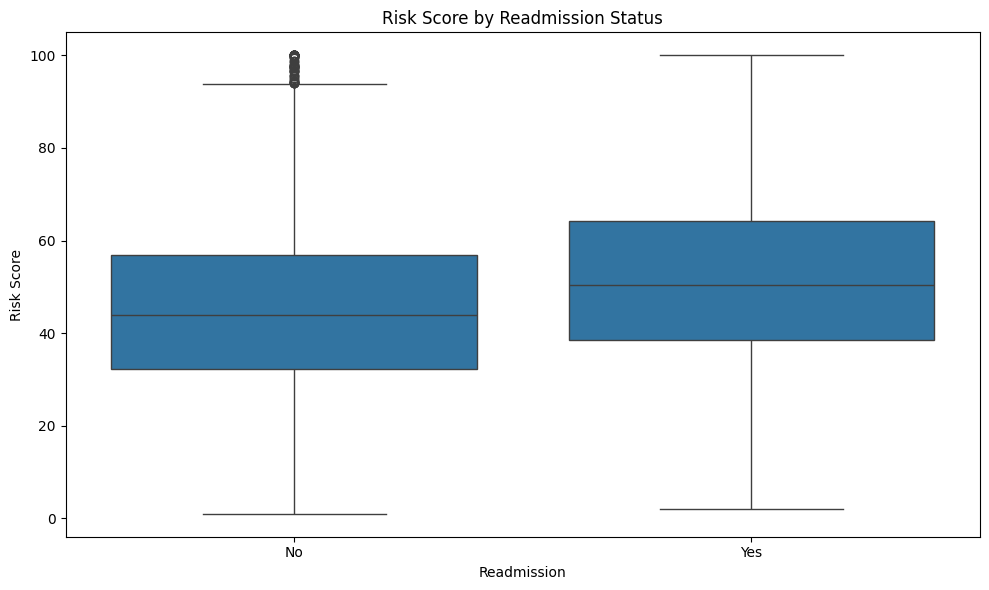

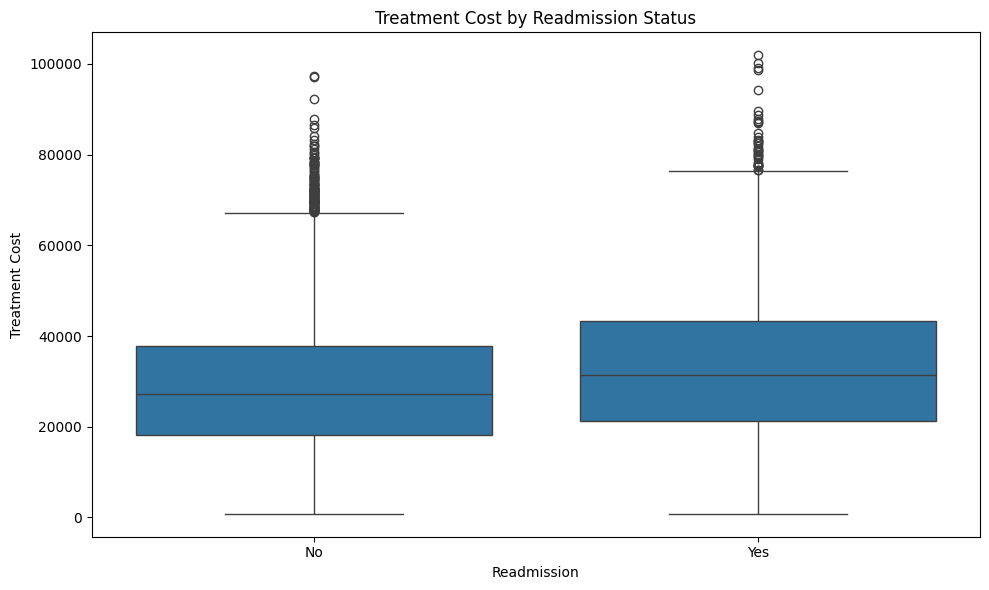

In [18]:
# Visualize the distributions
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="readmission",
    y="risk_score"
)

plt.title("Risk Score by Readmission Status")
plt.xlabel("Readmission")
plt.ylabel("Risk Score")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="readmission",
    y="treatment_cost"
)

plt.title("Treatment Cost by Readmission Status")
plt.xlabel("Readmission")
plt.ylabel("Treatment Cost")

plt.tight_layout()
plt.show()

## ANOVA Interpretation

One-way ANOVA tests whether the means of multiple groups are all equal.

### H₀
All disease groups have the same population mean risk score.

### H₁
At least one disease group has a different population mean risk score.

A statistically significant ANOVA result tells us that at least one
group differs.

It does NOT tell us exactly which groups differ.

Additional post-hoc tests would be required to determine the specific
pairwise differences.

In [19]:
# ANOVA: Risk Score across Diseases
disease_groups = [
    group["risk_score"].values
    for name, group in df.groupby("disease")
]

f_stat, p_value_anova = stats.f_oneway(*disease_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value_anova)

if p_value_anova < 0.05:
    print("Reject H0: Risk scores differ significantly across disease groups.")
else:
    print("Fail to reject H0: No statistically significant difference was detected.")

F-statistic: 590.8905973436384
P-value: 0.0
Reject H0: Risk scores differ significantly across disease groups.


In [20]:
# ANOVA: Treatment Cost across Admission Types
admission_cost_groups = [
    group["treatment_cost"].values
    for name, group in df.groupby("admission_type")
]

f_stat_admission, p_value_admission = stats.f_oneway(
    *admission_cost_groups
)

print("F-statistic:", f_stat_admission)
print("P-value:", p_value_admission)

if p_value_admission < 0.05:
    print("Reject H0: Treatment costs differ significantly across admission types.")
else:
    print("Fail to reject H0: No statistically significant difference was detected.")

F-statistic: 796.0817537917595
P-value: 1.527e-321
Reject H0: Treatment costs differ significantly across admission types.


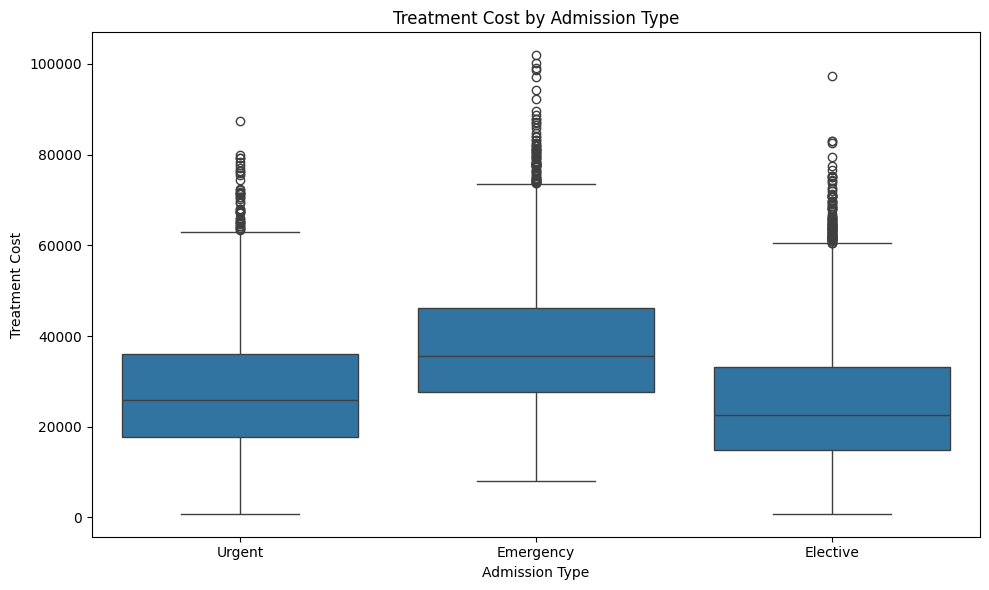

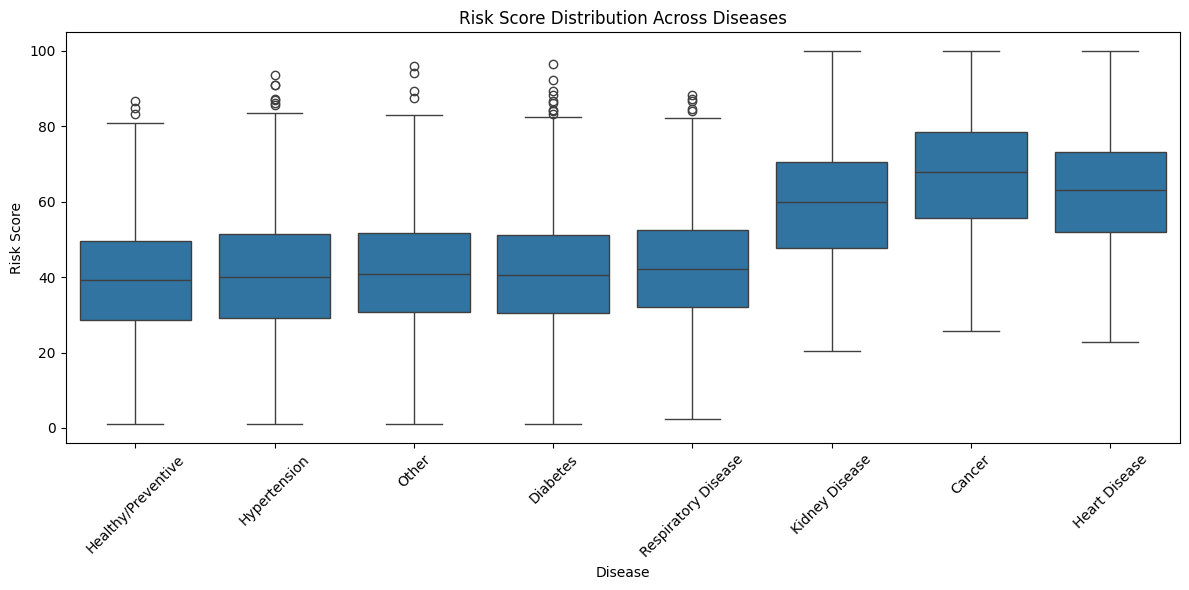

In [21]:
# visualize anova tests
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="admission_type",
    y="treatment_cost"
)

plt.title("Treatment Cost by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Treatment Cost")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="disease",
    y="risk_score"
)

plt.title("Risk Score Distribution Across Diseases")
plt.xlabel("Disease")
plt.ylabel("Risk Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Chi-square Test of Independence

The Chi-square test is used to examine whether two categorical
variables are statistically associated.

### H₀
The two categorical variables are independent.

### H₁
The two categorical variables are associated.

In this analysis:

Variable 1 → Admission Type

Variable 2 → Readmission Status

A significant result indicates an association between the variables.
It does not establish causation.

In [22]:
# Chi-square test
contingency_table = pd.crosstab(
    df["admission_type"],
    df["readmission"]
)

contingency_table

chi2, p_value_chi, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p_value_chi)

# decision
if p_value_chi < 0.05:
    print("Reject H0: Readmission is associated with admission type.")
else:
    print("Fail to reject H0: No statistically significant association was detected.")

Chi-square statistic: 25.940857976813035
Degrees of freedom: 2
P-value: 2.3281677144359543e-06
Reject H0: Readmission is associated with admission type.


In [23]:
# stestistical summary
statistical_results = pd.DataFrame({
    "Test": [
        "Readmission vs Risk Score",
        "Readmission vs Treatment Cost",
        "Risk Score across Diseases",
        "Treatment Cost across Admission Types",
        "Admission Type vs Readmission"
    ],
    "Test_Type": [
        "Welch's t-test",
        "Welch's t-test",
        "One-way ANOVA",
        "One-way ANOVA",
        "Chi-square"
    ],
    "Statistic": [
        t_stat,
        t_stat_cost,
        f_stat,
        f_stat_admission,
        chi2
    ],
    "P_Value": [
        p_value,
        p_value_cost,
        p_value_anova,
        p_value_admission,
        p_value_chi
    ]
})

statistical_results["Significant_at_0.05"] = (
    statistical_results["P_Value"] < 0.05
)

statistical_results.round(4)

,Test,Test_Type,Statistic,P_Value,Significant_at_0.05
0,Readmission vs Risk Score,Welch's t-test,14.8654,0.0,True
1,Readmission vs Treatment Cost,Welch's t-test,11.6758,0.0,True
2,Risk Score across Diseases,One-way ANOVA,590.8906,0.0,True
3,Treatment Cost across Admission Types,One-way ANOVA,796.0818,0.0,True
4,Admission Type vs Readmission,Chi-square,25.9409,0.0,True


## Day 9 — Statistical Analysis Observations

### 1. Readmission and Risk Score

A Welch's independent two-sample t-test was used to compare risk
scores between readmitted and non-readmitted patients.

The test produced a t-statistic of 14.8654 and a p-value of
2.2567 × 10⁻⁴⁸.

Since the p-value is below the 0.05 significance level, the null
hypothesis was rejected.

The average risk score difference between readmitted and
non-readmitted patients was approximately 6.70 points. Therefore,
the dataset provides statistical evidence of a difference in risk
scores between the two groups.

---

### 2. Readmission and Treatment Cost

A Welch's independent two-sample t-test was used to compare treatment
costs between readmitted and non-readmitted patients.

The test produced a t-statistic of 11.6758 and a p-value of
8.0147 × 10⁻³¹.

The null hypothesis was rejected at the 0.05 significance level.

The average treatment cost difference was approximately ₹4,759.81,
with readmitted patients having the higher average treatment cost
in this dataset.

---

### 3. Risk Score Across Disease Groups

A one-way ANOVA was used to compare average risk scores across
disease groups.

The test produced an F-statistic of 590.8906 with an extremely small
p-value.

The null hypothesis was rejected at the 0.05 significance level.

Therefore, there is statistical evidence that average risk scores
are not the same across all disease groups.

ANOVA indicates that at least one group differs, but it does not
identify the specific disease pairs responsible for the differences.

---

### 4. Treatment Cost Across Admission Types

A one-way ANOVA was used to compare treatment costs across admission
types.

The test produced an F-statistic of 796.0818 and a p-value of
approximately 1.527 × 10⁻³²¹.

The null hypothesis was rejected at the 0.05 significance level.

Therefore, there is statistical evidence that average treatment
costs differ across admission types.

---

### 5. Admission Type and Readmission

A Chi-square test of independence was used to examine the relationship
between admission type and readmission status.

The test produced a Chi-square statistic of 25.9409 with 2 degrees
of freedom and a p-value of approximately 2.3282 × 10⁻⁶.

The null hypothesis of independence was rejected.

Therefore, there is statistical evidence of an association between
admission type and readmission status in this dataset.

---

### Overall Statistical Interpretation

All five statistical tests produced p-values below the 0.05
significance level.

The results provide statistical evidence of differences or
associations involving risk score, treatment cost, disease,
admission type, and readmission status.

Statistical significance does not establish causation. The results
should therefore be interpreted as associations observed in this
dataset rather than causal relationships.

,Test,Test_Type,Statistic,P_Value,Significant_at_0.05
0,Readmission vs Risk Score,Welch's t-test,14.865359,2.257e-48,True
1,Readmission vs Treatment Cost,Welch's t-test,11.675755,8.015e-31,True
2,Risk Score across Diseases,One-way ANOVA,590.890597,0.000e+00,True
3,Treatment Cost across Admission Types,One-way ANOVA,796.081754,1.527e-321,True
4,Admission Type vs Readmission,Chi-square,25.940858,2.328e-06,True
